# 04 LSTM (PyTorch) - Tesla Stock Price Prediction

This is a complete, standalone pipeline for training a Long Short-Term Memory network to forecast Tesla's stock price using PyTorch.

In [18]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

sns.set(style='whitegrid')

### 1. Data Windowing & Scaling

In [19]:
def prepare_tesla_sequences(path, window=30):
    df = pd.read_csv(path).dropna()
    scaler = MinMaxScaler()
    scaled_data = scaler.fit_transform(df[['Close', 'Volume', 'RSI']])
    
    X, y = [], []
    for i in range(len(scaled_data) - window):
        X.append(scaled_data[i:i+window])
        y.append(scaled_data[i+window, 0])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32), scaler

X, y, scaler = prepare_tesla_sequences('../_data/stock_tesla.csv')
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

### 2. PyTorch LSTM Architecture

In [20]:
class StockDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).view(-1, 1)
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

class LSTMForecaster(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers=2):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True, dropout=0.2)
        self.fc = nn.Linear(hidden_dim, 1)
        
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = LSTMForecaster(3, 64).to(device)
train_loader = DataLoader(StockDataset(X_train, y_train), batch_size=16, shuffle=False)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

### 3. Training Loop (Complete)
Executing 20 epochs of sequential training.

In [21]:
model.train()
for epoch in range(20):
    for x_batch, y_batch in train_loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        preds = model(x_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()
    if (epoch+1) % 5 == 0: print(f"Epoch {epoch+1}, Loss: {loss.item():.6f}")

Epoch 5, Loss: 0.000798
Epoch 10, Loss: 0.001182
Epoch 15, Loss: 0.000825
Epoch 20, Loss: 0.000784


### 4. Forecasting Visualization

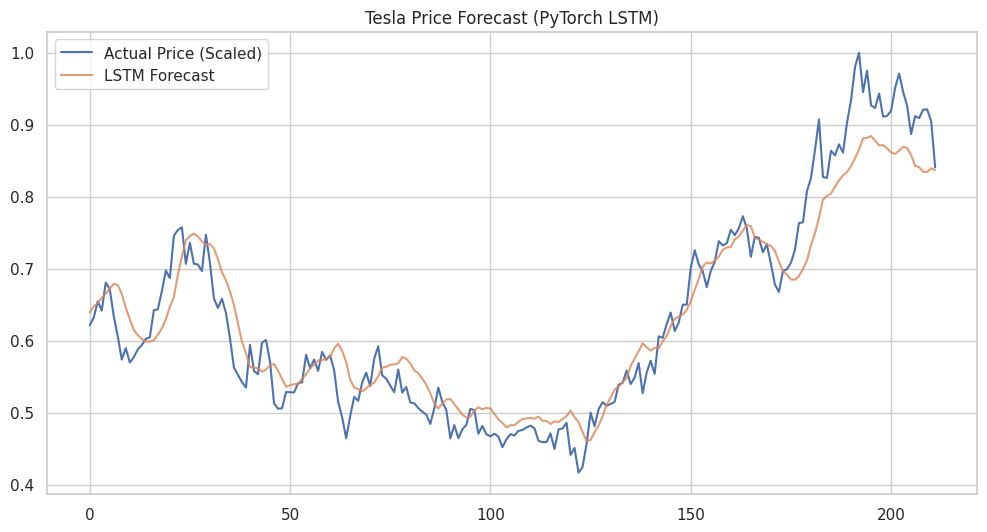

In [22]:
model.eval()
with torch.no_grad():
    y_pred = model(torch.tensor(X_test, dtype=torch.float32).to(device)).cpu().numpy()

plt.figure(figsize=(12, 6))
plt.plot(y_test, label='Actual Price (Scaled)')
plt.plot(y_pred, label='LSTM Forecast', alpha=0.8)
plt.title('Tesla Price Forecast (PyTorch LSTM)')
plt.legend()
plt.show()

### 5. Signal Classification and Backtesting
Build a more realistic buy/sell/hold strategy using future-return labels, a classifier head, and a simple strategy backtest.

Signal epoch 1, loss: 1.055245
Signal epoch 2, loss: 1.022741
Signal epoch 3, loss: 1.023091
Signal epoch 4, loss: 1.024946
Signal epoch 5, loss: 1.022931
Signal epoch 6, loss: 1.022845
Signal epoch 7, loss: 1.022861
Signal epoch 8, loss: 1.018908
Signal epoch 9, loss: 1.021361
Signal epoch 10, loss: 1.019082
Signal epoch 11, loss: 1.021298
Signal epoch 12, loss: 1.020565
Signal epoch 13, loss: 1.018673
Signal epoch 14, loss: 1.017138
Signal epoch 15, loss: 1.015784
Signal accuracy: 0.413
Trade count: 0, win rate: 0.000
Final equity factor: 1.000


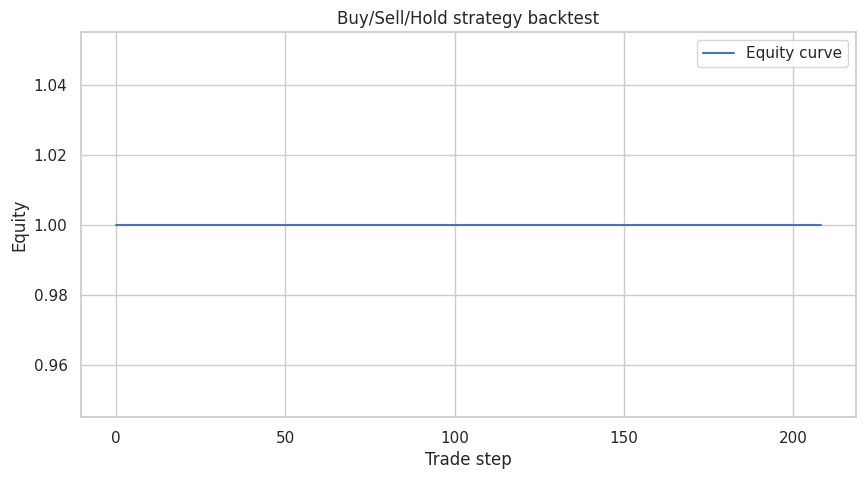

In [23]:
# Build classification features and buy/sell/hold labels
signal_df = pd.read_csv('../_data/stock_tesla.csv').dropna()
signal_df['ma_short'] = signal_df['Close'].rolling(5).mean()
signal_df['ma_long'] = signal_df['Close'].rolling(20).mean()
signal_df['volatility'] = signal_df['Close'].pct_change().rolling(10).std()
signal_df['vol_pct'] = signal_df['Volume'].pct_change()
signal_df = signal_df.dropna().reset_index(drop=True)

horizon = 3
threshold = 0.01

def make_signal_labels(close, horizon=3, threshold=0.01):
    future = close.shift(-horizon)
    returns = (future - close) / close
    labels = np.where(returns > threshold, 1, np.where(returns < -threshold, 2, 0))
    return labels[:-horizon]

signal_labels = make_signal_labels(signal_df['Close'], horizon=horizon, threshold=threshold)
feature_cols = ['Close', 'Volume', 'RSI', 'ma_short', 'ma_long', 'volatility', 'vol_pct']
feature_matrix = signal_df[feature_cols].iloc[:-horizon].values
feature_matrix = MinMaxScaler().fit_transform(feature_matrix).astype(np.float32)

def make_windows(features, labels, window=30):
    X, y = [], []
    for i in range(len(labels) - window):
        X.append(features[i:i+window])
        y.append(labels[i+window])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.int64)

X_sig, y_sig = make_windows(feature_matrix, signal_labels, window=30)
signal_train_size = int(len(X_sig) * 0.8)
X_train_sig, X_test_sig = X_sig[:signal_train_size], X_sig[signal_train_size:]
y_train_sig, y_test_sig = y_sig[:signal_train_size], y_sig[signal_train_size:]

class SignalDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

class LSTMSignalClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers=2, num_classes=3):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True, dropout=0.2)
        self.fc = nn.Linear(hidden_dim, num_classes)
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

signal_model = LSTMSignalClassifier(X_train_sig.shape[2], 64).to(device)
signal_loader = DataLoader(SignalDataset(X_train_sig, y_train_sig), batch_size=32, shuffle=True)
signal_criterion = nn.CrossEntropyLoss()
signal_optimizer = optim.Adam(signal_model.parameters(), lr=0.001)

for epoch in range(15):
    signal_model.train()
    total_loss = 0.0
    for x_batch, y_batch in signal_loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        signal_optimizer.zero_grad()
        logits = signal_model(x_batch)
        loss = signal_criterion(logits, y_batch)
        loss.backward()
        signal_optimizer.step()
        total_loss += loss.item() * x_batch.size(0)
    print(f"Signal epoch {epoch+1}, loss: {total_loss / len(signal_loader.dataset):.6f}")

signal_model.eval()
with torch.no_grad():
    logits = signal_model(torch.tensor(X_test_sig, dtype=torch.float32).to(device))
    probs = torch.softmax(logits, dim=-1).cpu().numpy()
    preds = np.argmax(probs, axis=1)
    confidence = probs.max(axis=1)

signal_map = {0: 'hold', 1: 'buy', 2: 'sell'}
signals = [signal_map[p] if conf > 0.6 else 'hold' for p, conf in zip(preds, confidence)]

# Backtesting with a 3-day realization horizon and simple transaction cost
start_idx = 30 + signal_train_size
close_prices = signal_df['Close'].iloc[start_idx:start_idx + len(signals)].values
future_prices = signal_df['Close'].shift(-horizon).iloc[start_idx:start_idx + len(signals)].values
returns = (future_prices - close_prices) / close_prices
transaction_cost = 0.001

equity = [1.0]
for sig, ret in zip(signals, returns):
    if sig == 'buy':
        pnl = ret - transaction_cost
    elif sig == 'sell':
        pnl = -ret - transaction_cost
    else:
        pnl = 0.0
    equity.append(equity[-1] * (1 + pnl))

signal_returns = np.array([
    (ret - transaction_cost) if sig == 'buy' else
    (-ret - transaction_cost) if sig == 'sell' else 0.0
    for sig, ret in zip(signals, returns)
])
trade_mask = np.array([sig != 'hold' for sig in signals])
win_rate = np.mean(signal_returns[trade_mask] > 0) if trade_mask.any() else 0.0
accuracy = np.mean(preds == y_test_sig)

print(f"Signal accuracy: {accuracy:.3f}")
print(f"Trade count: {trade_mask.sum()}, win rate: {win_rate:.3f}")
print(f"Final equity factor: {equity[-1]:.3f}")

plt.figure(figsize=(10, 5))
plt.plot(equity, label='Equity curve')
plt.title('Buy/Sell/Hold strategy backtest')
plt.xlabel('Trade step')
plt.ylabel('Equity')
plt.legend()
plt.show()

### 6. Model Saving

In [24]:
torch.save(model.state_dict(), '../_model/tesla_trading_lstm.pth')
torch.save(signal_model.state_dict(), '../_model/tesla_signal_lstm.pth')
print("Regression model and signal model saved.")

Regression model and signal model saved.
